# [LAB 06] 데이터 시각화 - 9. Pie Donut Plot

## #01. 준비작업 

### 1. 패키지 참조

In [17]:
from jussam import load_data
from helpers import *
import seaborn as sb

### 2. 데이터셋 불러오기 

In [18]:
origin = load_data("cafe_sales")
origin.head()

📚 서울의 한 오피스 상권 카페에서 점심시간(11:30~13:30) 동안 판매된 음료 주문 데이터


,주문번호,주문시각,구분,메뉴명,사이즈,금액
0,1001,2026-03-31 11:32,커피,아메리카노,레귤러,4500
1,1002,2026-03-31 11:34,커피,카페라떼,레귤러,5000
2,1003,2026-03-31 11:35,커피,아메리카노,라지,5000
3,1004,2026-03-31 11:36,커피,콜드브루,레귤러,5300
4,1005,2026-03-31 11:38,에이드,자몽에이드,레귤러,5800


### 3. 데이터 전처리 

In [19]:
df1 = origin[['메뉴명', '금액']].groupby('메뉴명').sum()
df1.sort_values('금액', ascending=False, inplace=True)
df1.head()

,금액
메뉴명,
아메리카노,60000
콜드브루,43400
카페라떼,41000
자몽에이드,35800
녹차,24500


## #02. PiePlot 시각화 

### 1.기본 구현 

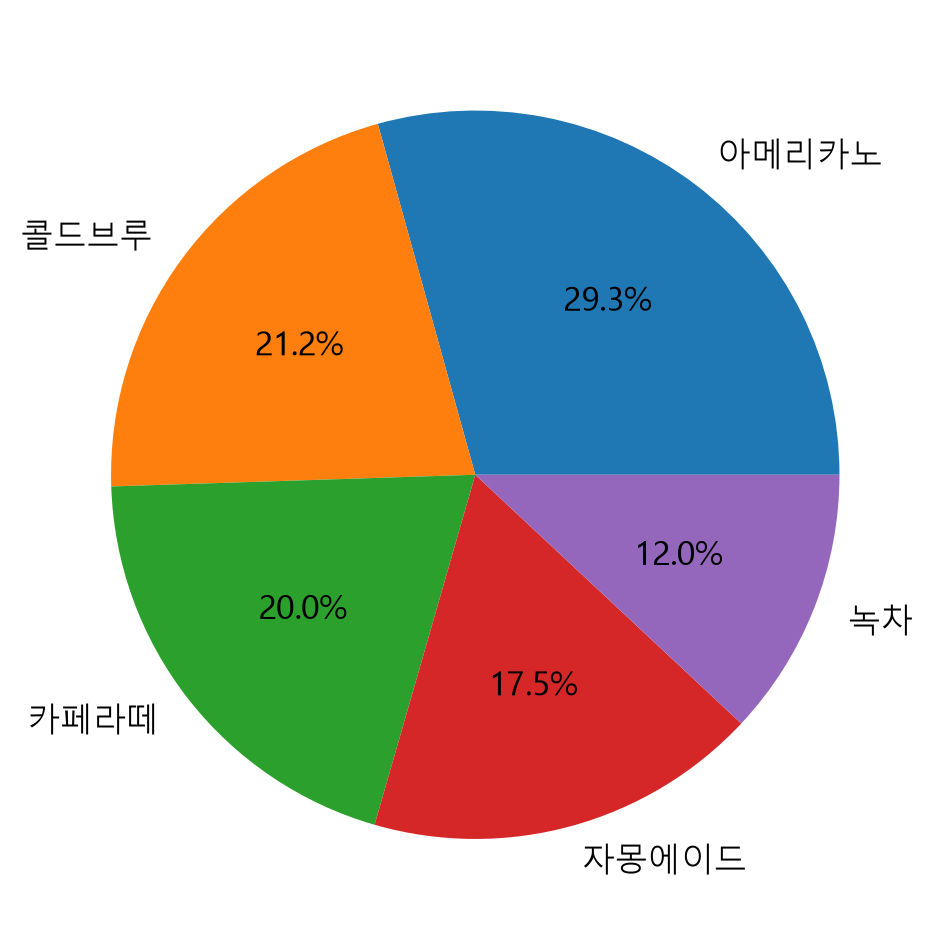

In [20]:
fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],       # 파이 차트로 표현할 데이터
       labels=df1.index,    # 각 데이터에 대한 레이블
       autopct='%.1f%%'     # 각 데이터의 비율을 표시 단위 
) 
my_plot.show()


### 2. 그래프 회전 

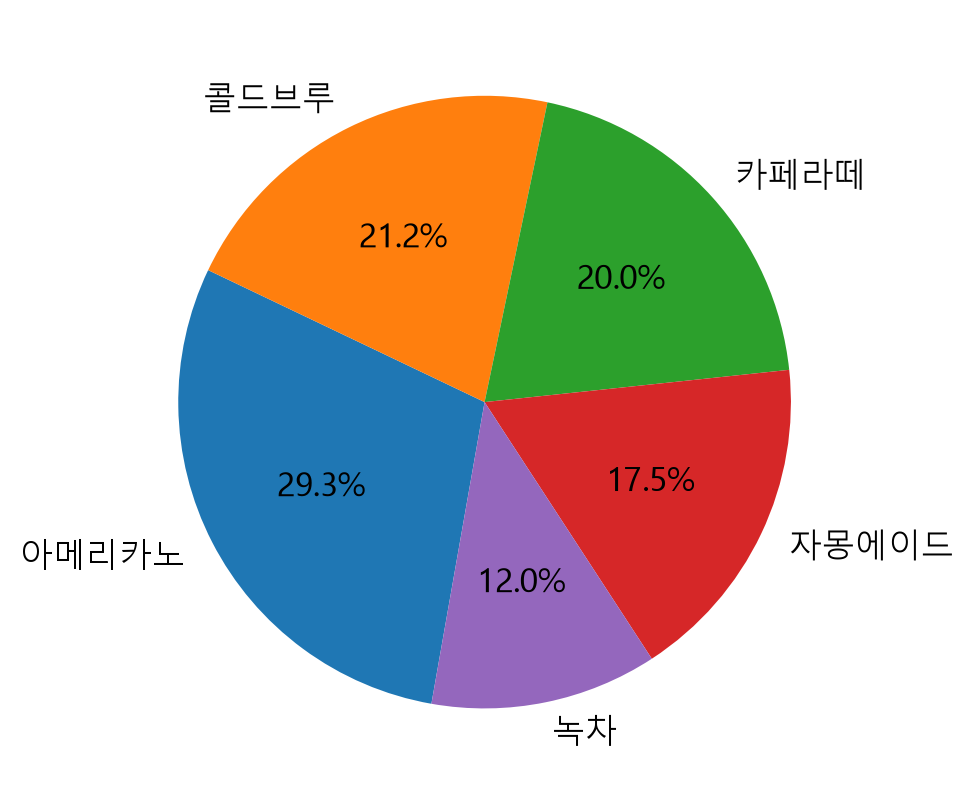

In [21]:
fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],        # 파이 차트로 표현할 데이터
       labels=df1.index,     # 각 데이터에 대한 레이블
       autopct='%.1f%%',     # 각 데이터의 비율을 표시 단위 
       startangle=260,       # 파이 차트의 시작 각도
       counterclock = False  # 시계방향으로 그리도록 설정 (기본값=반시계반향)
) 
my_plot.show()

### 3. 색상값 생성하기 

In [22]:
colors = sb.color_palette("Set2", n_colors=len(df1['금액']))
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235)]

### 4. 색상 설정하기 

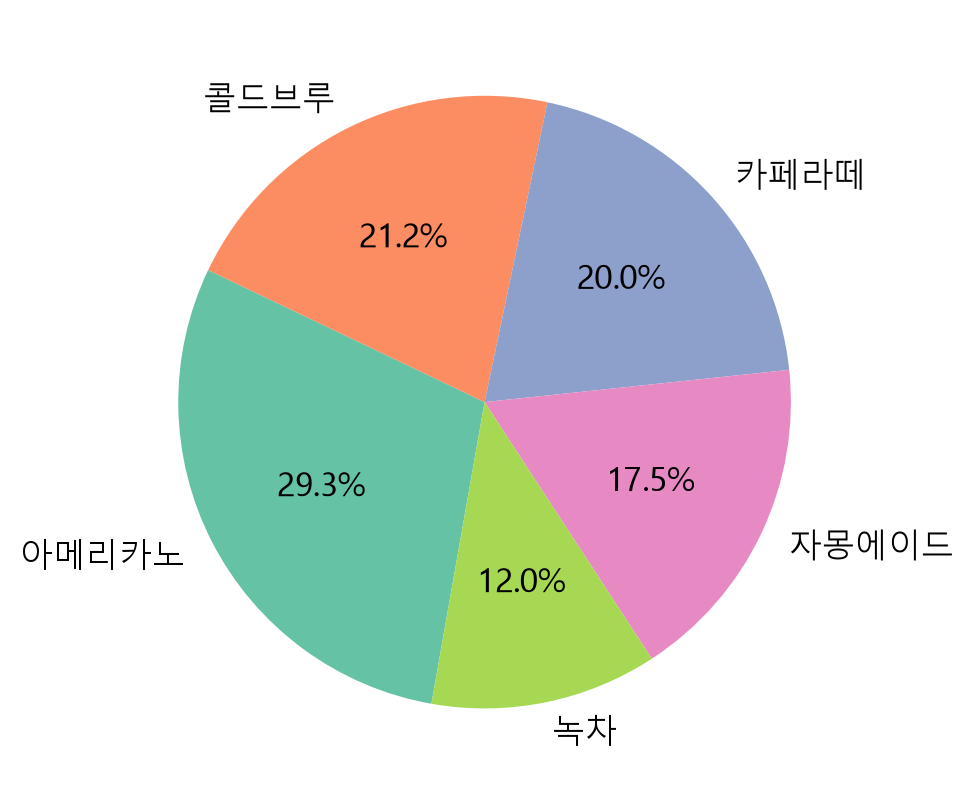

In [23]:
fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],       # 파이 차트로 표현할 데이터
       labels=df1.index,    # 각 데이터에 대한 레이블
       autopct='%.1f%%',    # 각 데이터의 비율을 표시 단위 
       startangle=260,      # 파이 차트의 시작 각도
       counterclock = False, # 시계방향으로 그리도록 설정 (기본값=반시계반향)
       colors=colors       # 각 데이터에 대한 색상 
) 
my_plot.show()

### 5. 특정 항목을 중심에서 분리하기 

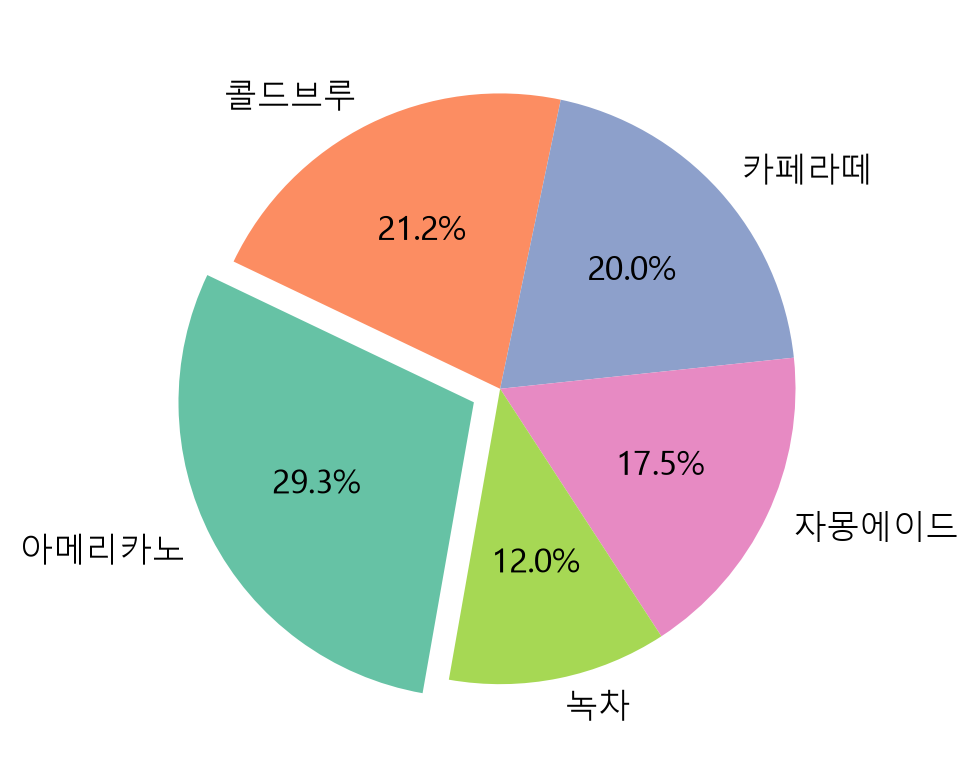

In [24]:
# 중심과의 거리를 데이터 순서대로 정의 (0~1 사이의 값)
# -> 데이터 수와 동일한 길이의 리스트로 정의 
explode = [0.1, 0, 0, 0, 0]

fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],       # 파이 차트로 표현할 데이터
       labels=df1.index,    # 각 데이터에 대한 레이블
       autopct='%.1f%%',    # 각 데이터의 비율을 표시 단위 
       startangle=260,      # 파이 차트의 시작 각도
       counterclock = False, # 시계방향으로 그리도록 설정 (기본값=반시계반향)
       colors=colors,       # 각 데이터에 대한 색상 
       explode=explode      # 중심과의 거리를 데이터 순서대로 정의 
) 
my_plot.show()

## #03. Donut Plot 

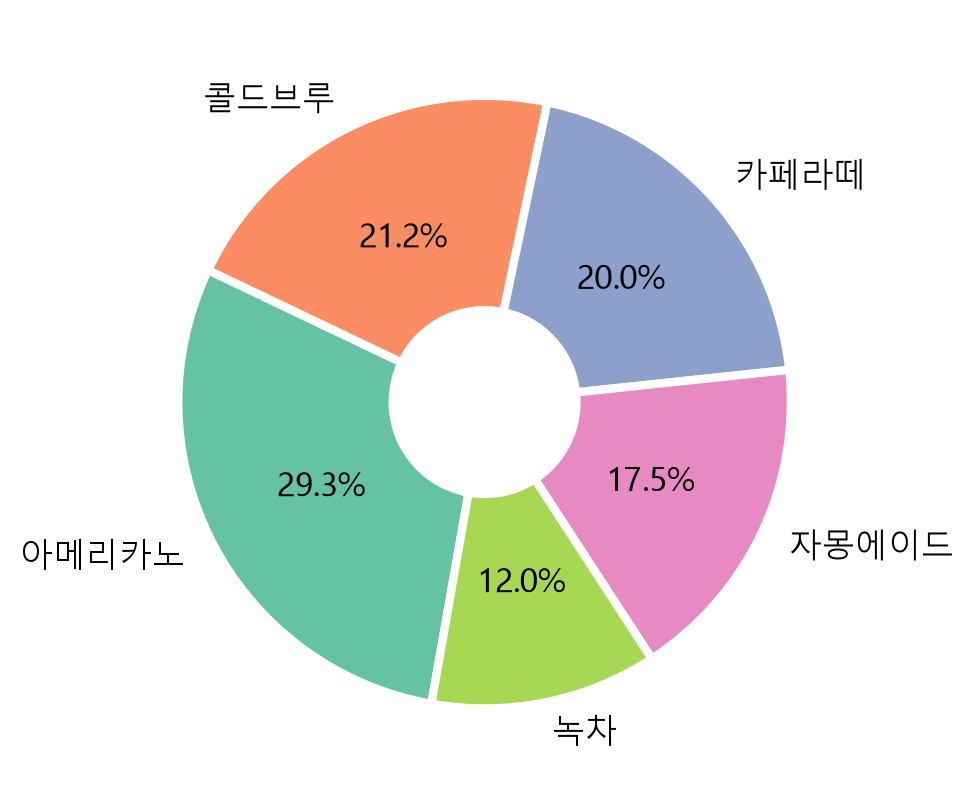

In [25]:
# 파이 차트의 조각(wedge) 스타일을 설정하는 딕셔너리 
# -> 두께, 테두리 색상, 테두리 두께 
wedgeprops = {'width':0.7, 'edgecolor':'#ffffff', 'linewidth':3}

fig, ax = my_plot.init(width=500,height=500)
ax.pie(x=df1['금액'],        # 파이 차트로 표현할 데이터
       labels=df1.index,     # 각 데이터에 대한 레이블
       autopct='%.1f%%',     # 각 데이터의 비율을 표시 단위 
       startangle=260,       # 파이 차트의 시작 각도
       counterclock = False, # 시계방향으로 그리도록 설정 (기본값=반시계반향)
       colors=colors,         # 각 데이터에 대한 색상 
       wedgeprops=wedgeprops # 파이 차트의 조각 스타일 설정 
) 
my_plot.show()

### 1. 파이 그래프 

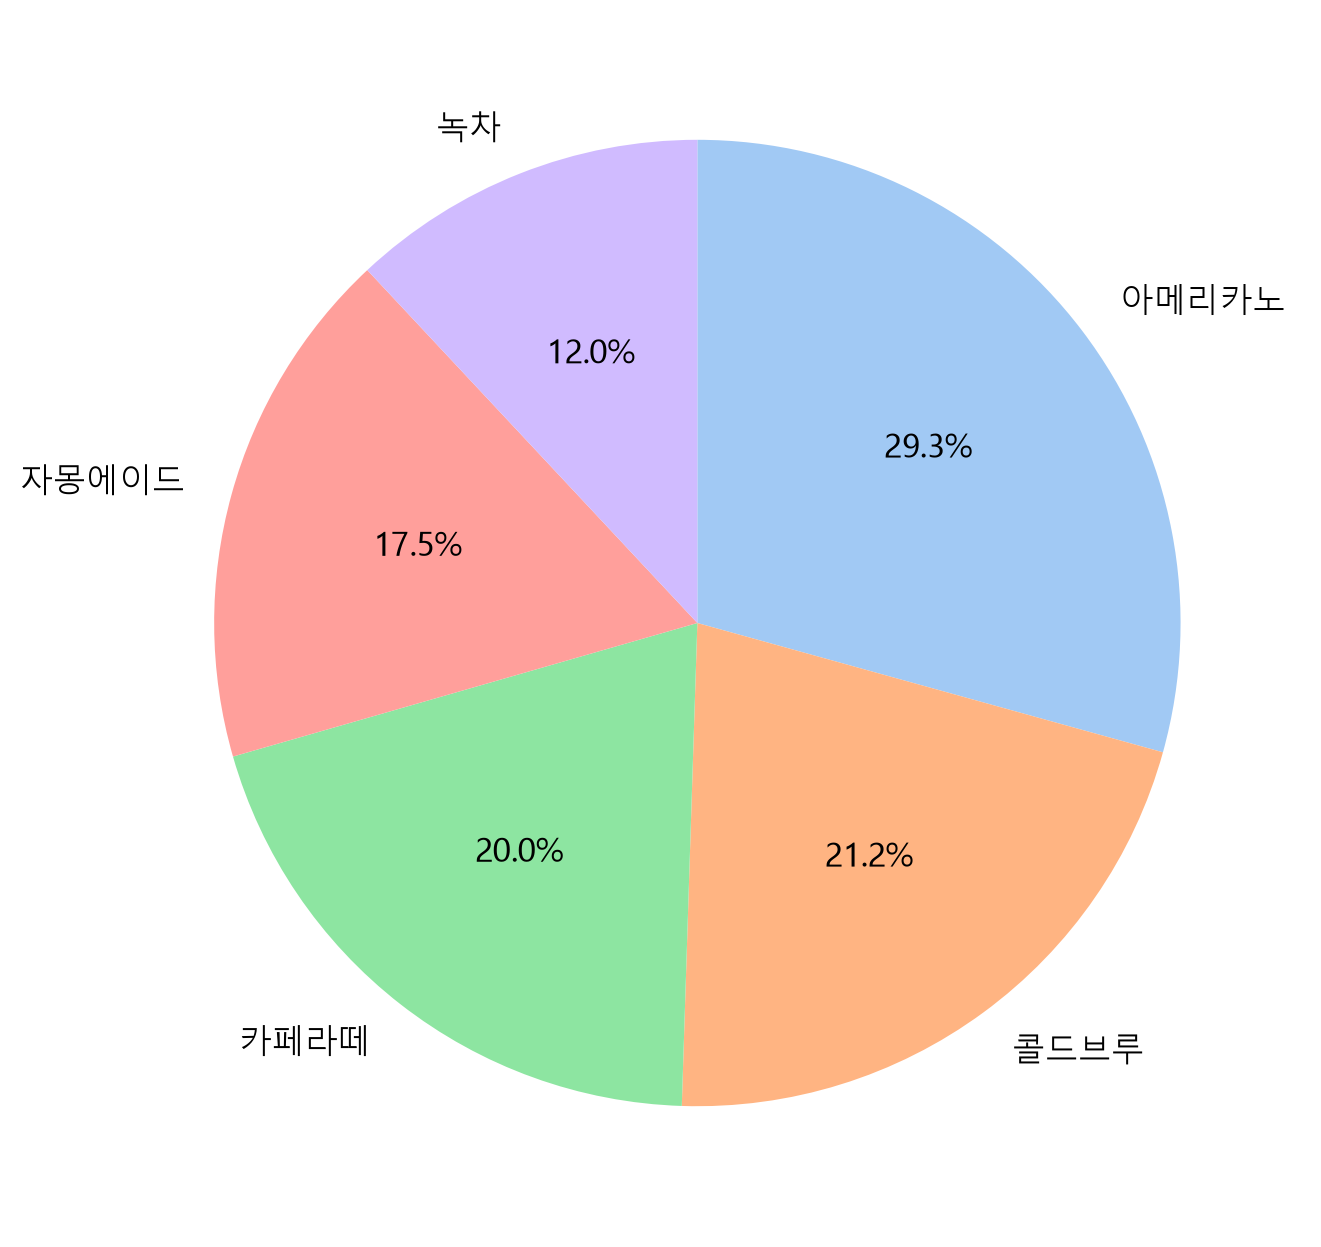

In [26]:
my_plot.pieplot(x=df1['금액'], labels=df1.index, palette='pastel')

### 2. 도넛 그래프 

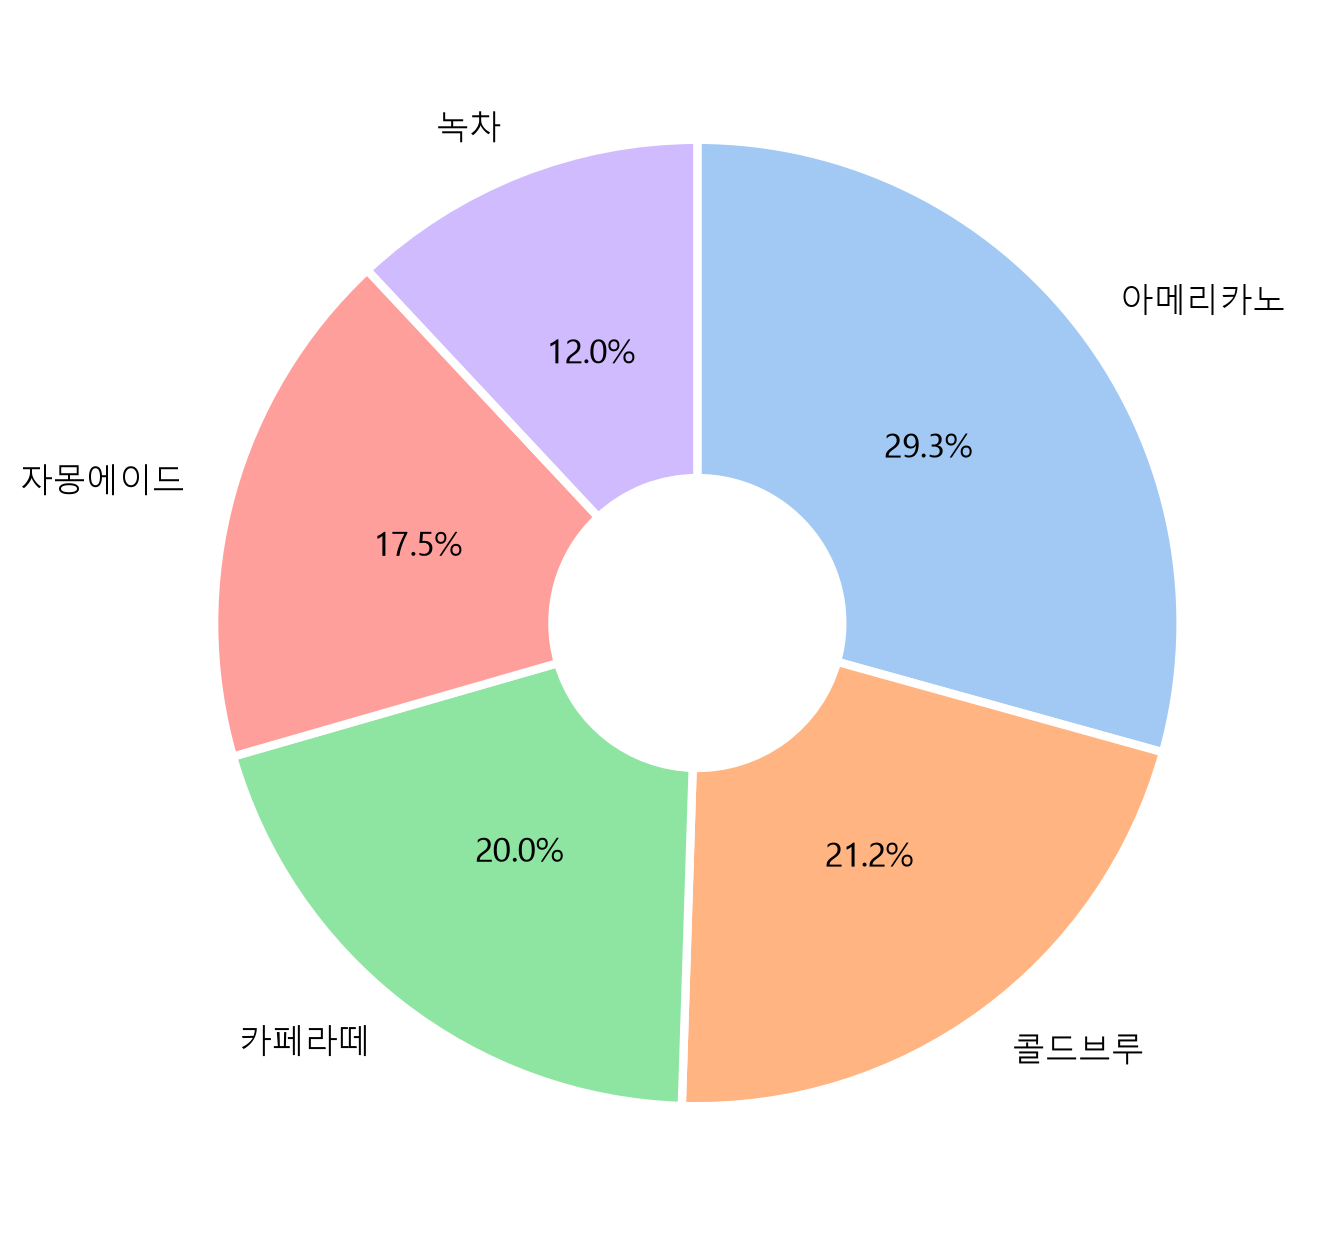

In [27]:
my_plot.pieplot(x=df1['금액'], labels=df1.index, palette="pastel",
                donutchart=True)

## #01. 연습문제 

In [28]:
from jussam import load_data
from helpers import *
import seaborn as sb

In [29]:
origin = load_data("icecream_sales")
origin.head()

📚 '달콤 스쿱' 아이스크림 가게의 매출 데이터 (인덱스 없음)


,Date,Flavor,Topping,Price,Quantity
0,2023-07-01,초콜릿,아몬드,3500,20.000
1,2023-07-01,바닐라,초코시럽,3000,25.000
2,2023-07-01,딸기,연유,3200,18.000
3,2023-07-02,민트초코,초코칩,3800,15.000
4,2023-07-02,초콜릿,아몬드,3500,22.000


In [30]:
# Flavor별 Quantity 합계를 계산 

In [31]:
df = origin[['Flavor','Quantity']].groupby('Flavor').sum()
df.sort_values('Quantity', ascending=False, inplace=True)
df.head()

,Quantity
Flavor,
바닐라,83.000
딸기,65.000
초콜릿,60.000
민트초코,32.000


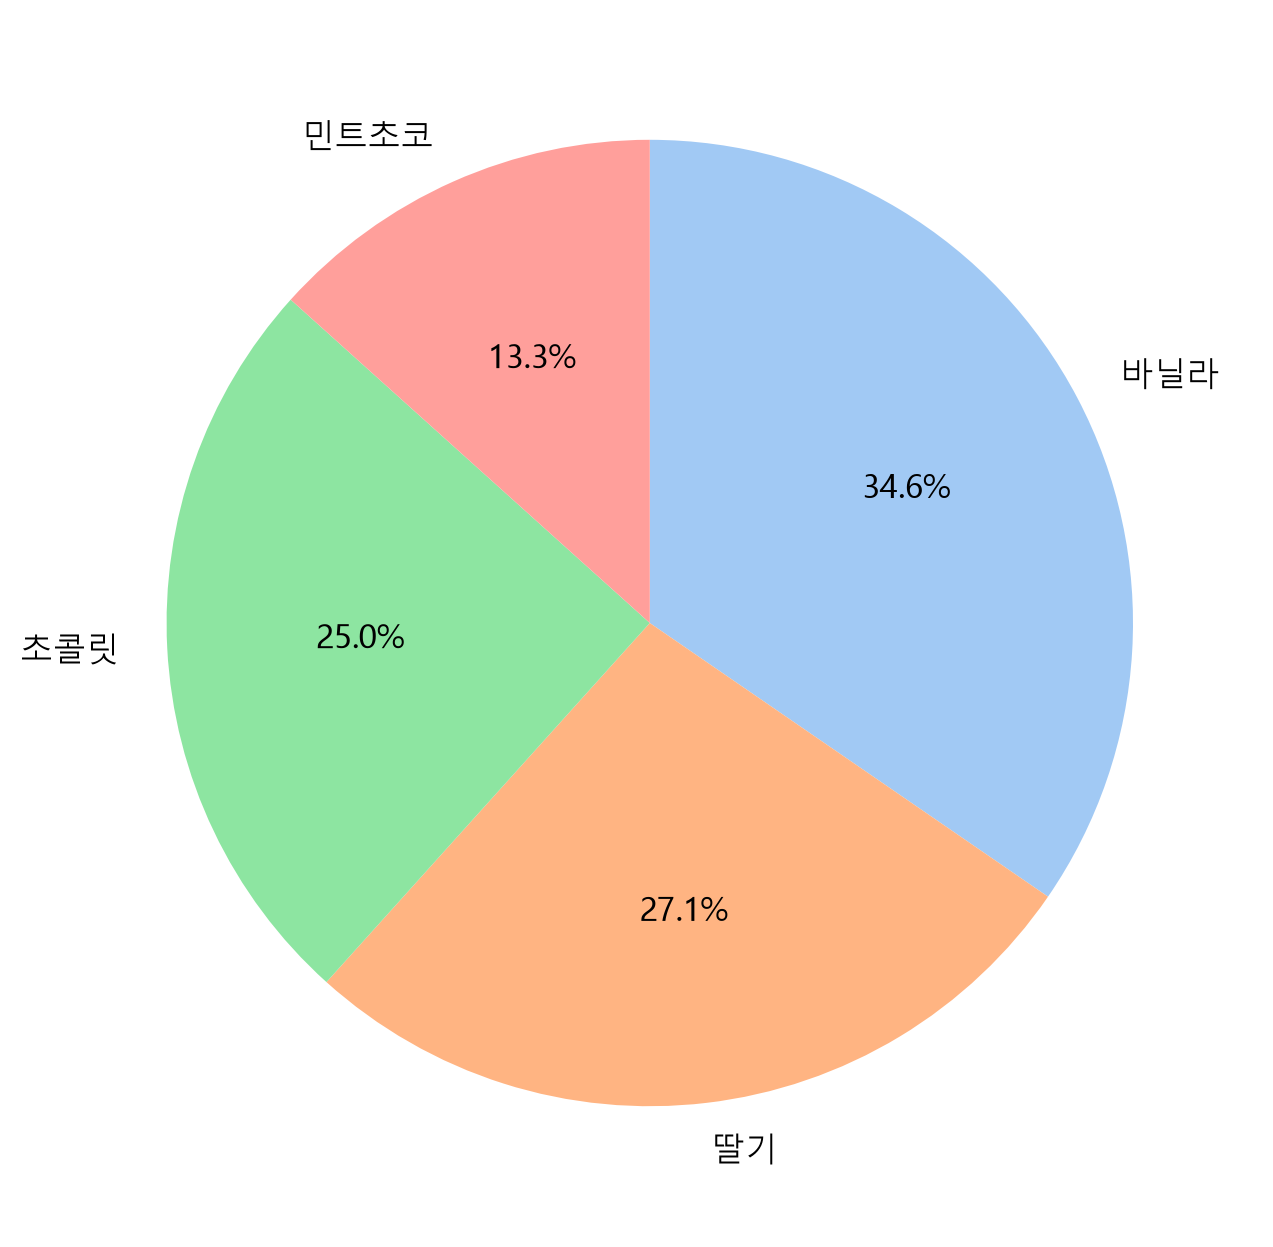

In [32]:
my_plot.pieplot(x=df['Quantity'], labels=df.index, palette="pastel")